In [9]:
# Awesome! Here's an improved and **detailed version** of your Module 14 — tailored for your project flow and long-term tracking:

# ---

# ### 🧩 **Module 14: Model Evaluation & Improvement**

# #### 🎯 **Objective:**  
# Understand how well your model performs, spot weaknesses, and make smart decisions to improve it.

# ---

# #### ✅ **Step 1: Review Model Metrics**
# After training, review the printed results or from code:

# ```python
# results = model.train(...)  # or model.val()
# results_dict = results.results_dict
# ```

# Key metrics:

# | Metric              | Meaning                                 | Good Value  |
# |---------------------|------------------------------------------|-------------|
# | `precision`         | Correct detections out of predictions    | > 0.80      |
# | `recall`            | Detected objects out of all ground truths| > 0.85      |
# | `mAP50`             | Avg precision with 50% IoU threshold     | > 0.90      |
# | `mAP50-95`          | Avg precision across IoU 0.5–0.95        | > 0.70      |
# | `fitness`           | YOLO’s internal score                    | Higher = Better |

# ---

# #### ✅ **Step 2: Visual Evaluation**
# Use:
# ```python
# results = model.predict("test.jpg", save=True, conf=0.5)
# ```

# Ask yourself:
# - ❌ Are some objects **missed**?
# - ❌ Are there **false detections** (wrong labels)?
# - ❌ Are boxes **too big/small**?

# ---

# #### ✅ **Step 3: Collect More Data or Fix It**
# Depending on errors:
# | Problem | Fix |
# |--------|-----|
# | Missed object | Add similar cases to training set |
# | Wrong detection | Check label accuracy / false positives |
# | Broken boxes | Add better annotated examples |
# | Overfitting | Add validation images or use `val` set |

# ---

# #### ✅ **Step 4: Retrain with New Data**
# - Add raw images → label them (Module 12)
# - Place in `images/train` and `labels/train`
# - Rebuild dataset:
# ```bash
# yolo train data=data.yaml model=yolov8n.pt epochs=30
# ```

# Optional:
# - Freeze backbone
# - Use image augmentation
# - Fine-tune with pretrained weights

# ---

# #### ✅ **Step 5: Track Each Version**
# Store:
# - `best.pt` (versioned)
# - `results_dict` in CSV or JSON
# - Visual predictions in `/runs/`

# ---

# Let me know if you'd like:
# - ✅ A Jupyter notebook template to automate evaluation + logging
# - ✅ Helper script to rename and version your models after training

# You’re now at the stage of **continuous model improvement** — just like real production workflows. 🔁💪

/tmp/ipykernel_1911/963103339.py:31: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


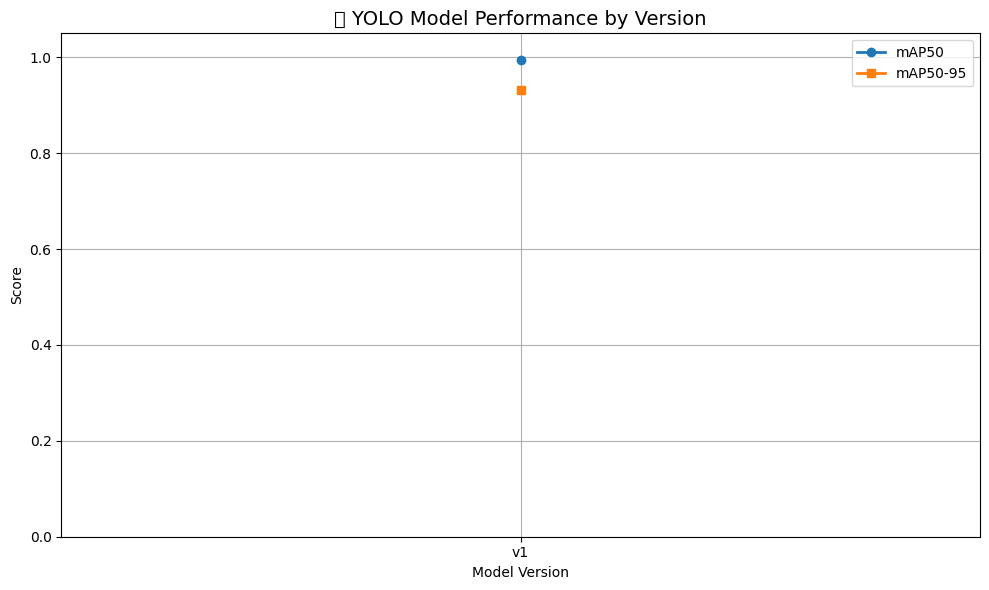


📝 Model Performance Table:


,Version,mAP50,mAP50-95,Precision,Recall,Dataset Size,epochs,Notes
0,v1,0.995,0.932378,0.994221,1.0,11,50,Image From Internet


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ========================
# Load your CSV performance log
# ========================
log_path = "training_log.csv"  # Replace with your actual CSV path
df = pd.read_csv(log_path)

# Make sure Version column is string
df['Version'] = df['Version'].astype(str)

# ========================
# Plot mAP scores
# ========================
plt.figure(figsize=(10, 6))

# Plot mAP50
plt.plot(df['Version'], df['mAP50'], label='mAP50', marker='o', color='tab:blue', linewidth=2)

# Plot mAP50-95
plt.plot(df['Version'], df['mAP50-95'], label='mAP50-95', marker='s', color='tab:orange', linewidth=2)

# Customize plot
plt.title("🧠 YOLO Model Performance by Version", fontsize=14)
plt.xlabel("Model Version")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ========================
# Optional: Print table for context
# ========================
print("\n📝 Model Performance Table:")
display_cols = ["Version", "mAP50", "mAP50-95", "Precision", "Recall", "Dataset Size","epochs", "Notes"]
display(df[display_cols])
